#### Getting door and hole areas

In [14]:
from pathlib import Path

from cubes.construct.utilities import (
    ModifiedIDF as IDF,
)

EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"

# Set IDD path
IDF.setiddname(str(Path(EPLUS_PATH) / "Energy+.idd"))

idf = IDF("/workspaces/CUBES/beizaee_validation/building_model_full_afn.idf")

doors = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "door" in sf.Name.lower():
        doors[sf.Name] = sf.area

holes = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "hole" in sf.Name.lower():
        holes[sf.Name] = sf.area


In [16]:
doors

{'kitchen_Wall_4_0_0_0_0_0_Door': np.float64(2.1999999999999997),
 'kitchen_Partition_5_0_0_0_0_0_Door': np.float64(2.1999999999999993),
 'hall_downstairs_Partition_3_0_0_0_0_0_Door_10015': np.float64(2.1999999999999997),
 'backroom_Partition_5_0_0_0_0_0_Door': np.float64(1.4700000000000006),
 'hall_downstairs_Partition_2_0_0_0_0_0_Door_10019': np.float64(1.4700000000000006),
 'hall_downstairs_Wall_5_0_0_0_0_0_Door': np.float64(2.1999999999999997),
 'hall_downstairs_Partition_6_0_0_0_0_0_Door': np.float64(2.2),
 'front_room_Partition_4_0_0_0_0_0_Door_10033': np.float64(2.2),
 'bathroom_Partition_6_0_0_0_0_0_Door': np.float64(1.81183619795976),
 'hall_upstairs_Partition_3_0_0_0_0_0_Door_10040': np.float64(1.8118361979597597),
 'bedroom_1_Partition_5_0_0_0_0_0_Door': np.float64(2.1999999999999975),
 'hall_upstairs_Partition_2_0_0_0_0_0_Door_10042': np.float64(2.1999999999999975),
 'hall_upstairs_Partition_4_0_0_0_0_0_Door': np.float64(1.4625737889876786),
 'wash_closet_Partition_2_0_0_0_

In [15]:
holes

{'hall_downstairs_Ceiling_1_0_6_0_6_0_Hole': np.float64(1.966980228796134),
 'hall_upstairs_Floor_0_0_0_0_0_0_Hole_10029': np.float64(1.9669802287961342)}


#### Testing the build function

In [1]:

import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig


files_dir = "/workspaces/CUBES/beizaee_validation/misc/input"
bc_file_path = "/workspaces/CUBES/cubes/data/buildingconfigs/thermostat_experiment/2023/case0.json"

materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)
#building=Building(BC,materials_evaluator(),windows_evaluator())
building.build()
idf = building.get_idf()


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)
/workspaces/CUBES/cubes/construct/utilities.py:68: RuntimeWarning: invalid value encountered in divide
  return n / np.linalg.norm(n)


Added opening between front_room and hall_downstairs (vertical, 2.20 m²)
Added opening between front_room and backroom (vertical, 2.20 m²)
Added opening between front_room and kitchen (vertical, 1.97 m²)
Added opening between kitchen and hall_downstairs (vertical, 2.20 m²)
Added opening between backroom and kitchen (vertical, 2.20 m²)
Added opening between bedroom_3 and hall_upstairs (vertical, 2.20 m²)
Added opening between bedroom_1 and hall_upstairs (vertical, 2.20 m²)
Added opening between bathroom and hall_upstairs (vertical, 2.20 m²)
Added opening between bedroom_2 and hall_upstairs (vertical, 2.20 m²)
Added opening between hall_downstairs and hall_upstairs (horizontal, 1.88 m²)
🗓️ Added AlwaysOnSchedule.
🗓️ Added AlwaysOffSchedule.
🗑️ Removed old infiltration, ventilation, and mixing objects.
🔧 AFN controls set up.
🔵 Internal Door & Hole Openings Created: 10
🔵 External Surfaces with Cracks: 66
🔵 External Fenestrations with Cracks: 24
🔵 User-defined openings created: 10
🔵 Added 5

/usr/local/lib/python3.9/dist-packages/eppy/geometry/surface.py:63: RuntimeWarning: invalid value encountered in scalar divide
  mag = (x_val / magnitude, y_val / magnitude, z_val / magnitude)


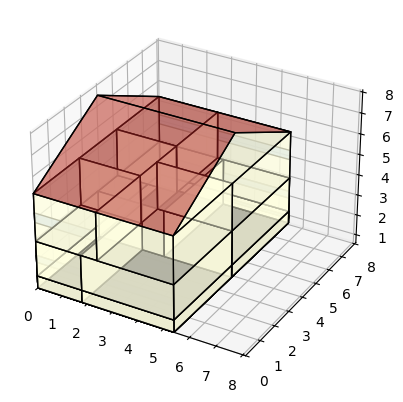

In [2]:
idf.view_model()

In [3]:
import matplotlib.pyplot as plt

def plot_idf_surfaces(idf, surface_names, colors=None, show_labels=True):
    """
    Plot selected IDF surfaces in 2D (top-down XY projection).

    Args:
        idf: The IDF object.
        surface_names (list[str]): List of surface names to plot.
        colors (list[str], optional): List of matplotlib colors to use.
                                      Defaults to auto color cycle.
        show_labels (bool): Whether to label surfaces by name.
    """
    surfaces = [
        sf for sf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
        if sf.Name in surface_names
    ]

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    plt.figure()
    for i, sf in enumerate(surfaces):
        coords = sf.coords + [sf.coords[0]]  # close the polygon
        xs, ys, zs = zip(*coords)
        plt.plot(xs, ys, color=colors[i % len(colors)], label=sf.Name)
        if show_labels:
            plt.text(sum(xs)/len(xs), sum(ys)/len(ys), sf.Name, fontsize=8)

    plt.axis('equal')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title("Selected IDF Surfaces")
    plt.legend()
    plt.show()


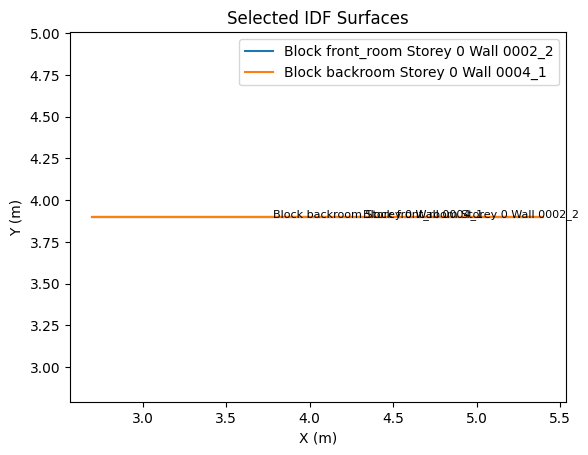

In [4]:
plot_idf_surfaces(idf, ["Block front_room Storey 0 Wall 0002_2",
                        "Block backroom Storey 0 Wall 0004_1"])


In [5]:
idf.save("test.idf")

In [6]:
doors = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "door" in sf.Name.lower():
        doors[sf.Name] = sf.area

holes = {}
for sf in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    if "hole" in sf.Name.lower():
        holes[sf.Name] = sf.area


In [7]:
holes

{'Block hall_downstairs Storey 0 Roof 0001_1_hole': np.float64(1.8809999999646108),
 'Block hall_upstairs Storey 0 Floor 0001_1_hole': np.float64(1.8809999999646108)}

In [8]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file

idf_file = "/workspaces/CUBES/beizaee_validation/test.idf"

# Define the weather file path
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"

# ✅ Initialize IDF with both the IDF file and Weather file
idf = IDF(idf_file, weather_file_path)

# Print IDF summary
print("IDF Version:", idf.idfobjects["VERSION"])
print("Number of objects:", len(idf.idfobjects))

# Define the test function to run the simulation
def test_idf(idf):
    # Define paths for saving and output
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    Path(env_data_path).mkdir(parents=True, exist_ok=True)

    # Save the modified IDF
    idf.save(filename=os.path.join(env_data_path, "test1.idf"))

    # Define output directory
    output_directory = os.path.join(env_data_path, "output/")
    Path(output_directory).mkdir(parents=True, exist_ok=True)

    # ✅ Run EnergyPlus simulation (No need to pass weather file separately now)
    idf.run(output_directory=output_directory)

# Run the test function
test_idf(idf)


IDF Version: [
Version,
    9.5;                      !- Version Identifier
]
Number of objects: 821

/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/CUBES/cubes/data/weather/loughborough.epw --output-directory /workspaces/CUBES/beizaee_validation/input_case_1/output --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd /workspaces/CUBES/beizaee_validation/in.idf

EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2025.08.05 17:20
Initializing Response Factors
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "ROOF-CONSTRUCTION"
Calculating CTFs for "GROUNDFLOOR-CONSTRUCTION"
Calculating CTFs for "FLOOR-CONSTRUCTION"
Calculating CTFs for "INTERNALWALL-CONSTRUCTION"
Calculating CTFs for "PARTITIONDOOR-CONSTRUCTION"
Calculating CTFs for "FURNITURE-CONSTRUCTION"
Calculating CTFs for "LAST FLOOR-CONSTRUCTION"
Calculating CTFs for "LAST FLOOR-CONSTRUCTION"
Calculating CTFs for "SUBFLOOR-CONSTRUCTION"
Initializing Window Op

Program terminated: EnergyPlus Terminated--Error(s) Detected.


EnergyPlusRunError: 

Contents of EnergyPlus error file at /workspaces/CUBES/beizaee_validation/input_case_1/output/eplusout.err
Program Version,EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2025.08.05 17:20,
   ************* Beginning Zone Sizing Calculations
   ** Warning ** RunPeriod: object=RUN PERIOD 1, start weekday (TUESDAY) does not match the start year (2023), corrected to SUNDAY.
   ** Warning ** Weather file location will be used rather than entered (IDF) Location object.
   **   ~~~   ** ..Location object=DENVER_STAPLETON_CO_USA_WMO_724690
   **   ~~~   ** ..Weather File Location=NA NA NA Shiny Weather Data WMO#=NA
   **   ~~~   ** ..due to location differences, Latitude difference=[12.98] degrees, Longitude difference=[103.62] degrees.
   **   ~~~   ** ..Time Zone difference=[7.0] hour(s), Elevation difference=[94.48] percent, [1522.00] meters.
   ** Warning ** ProcessScheduleInput: Schedule:Compact="ALWAYS RADIATOR TEMP", Blank Schedule Type Limits Name input -- will not b

#### Adding new materials to pickle

In [ ]:
import pickle
import pandas as pd
from cubes.construct.material import Material, InfraredTransparentMaterial
materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")

door_material = Material(
    name="Door_WoodSolid_35mm",   # new clear name
    rho=700.0,                    # Density [kg/m3]
    cp=2390.0,                    # Specific Heat [J/kg-K]
    k=0.19,                       # Conductivity [W/m-K]
    roughness="Rough",            # Surface roughness
    thermal_absorptance=0.9,
    solar_absorptance=0.5,
    visual_absorptance=0.5
)

# Then add it to your materials dict
materials["Door_WoodSolid_35mm"] = door_material

materials["IRTMaterial"] = InfraredTransparentMaterial(name="IRTMaterial")


# Save to pickle file
path = "/workspaces/CUBES/cubes/materials.pickle"
with open(path, "wb") as f:
    pickle.dump(materials, f)

